In [23]:
import os
import tarfile
import urllib
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [24]:
fetch_housing_data()

In [25]:
import pandas as pd
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    print(csv_path)
    return pd.read_csv(csv_path)

In [26]:
housing=load_housing_data()
housing.info()

datasets\housing\housing.csv
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [27]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [28]:
#getting a quick description of the dataset 
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [29]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [30]:
#to get the summary of the numerical attributes
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

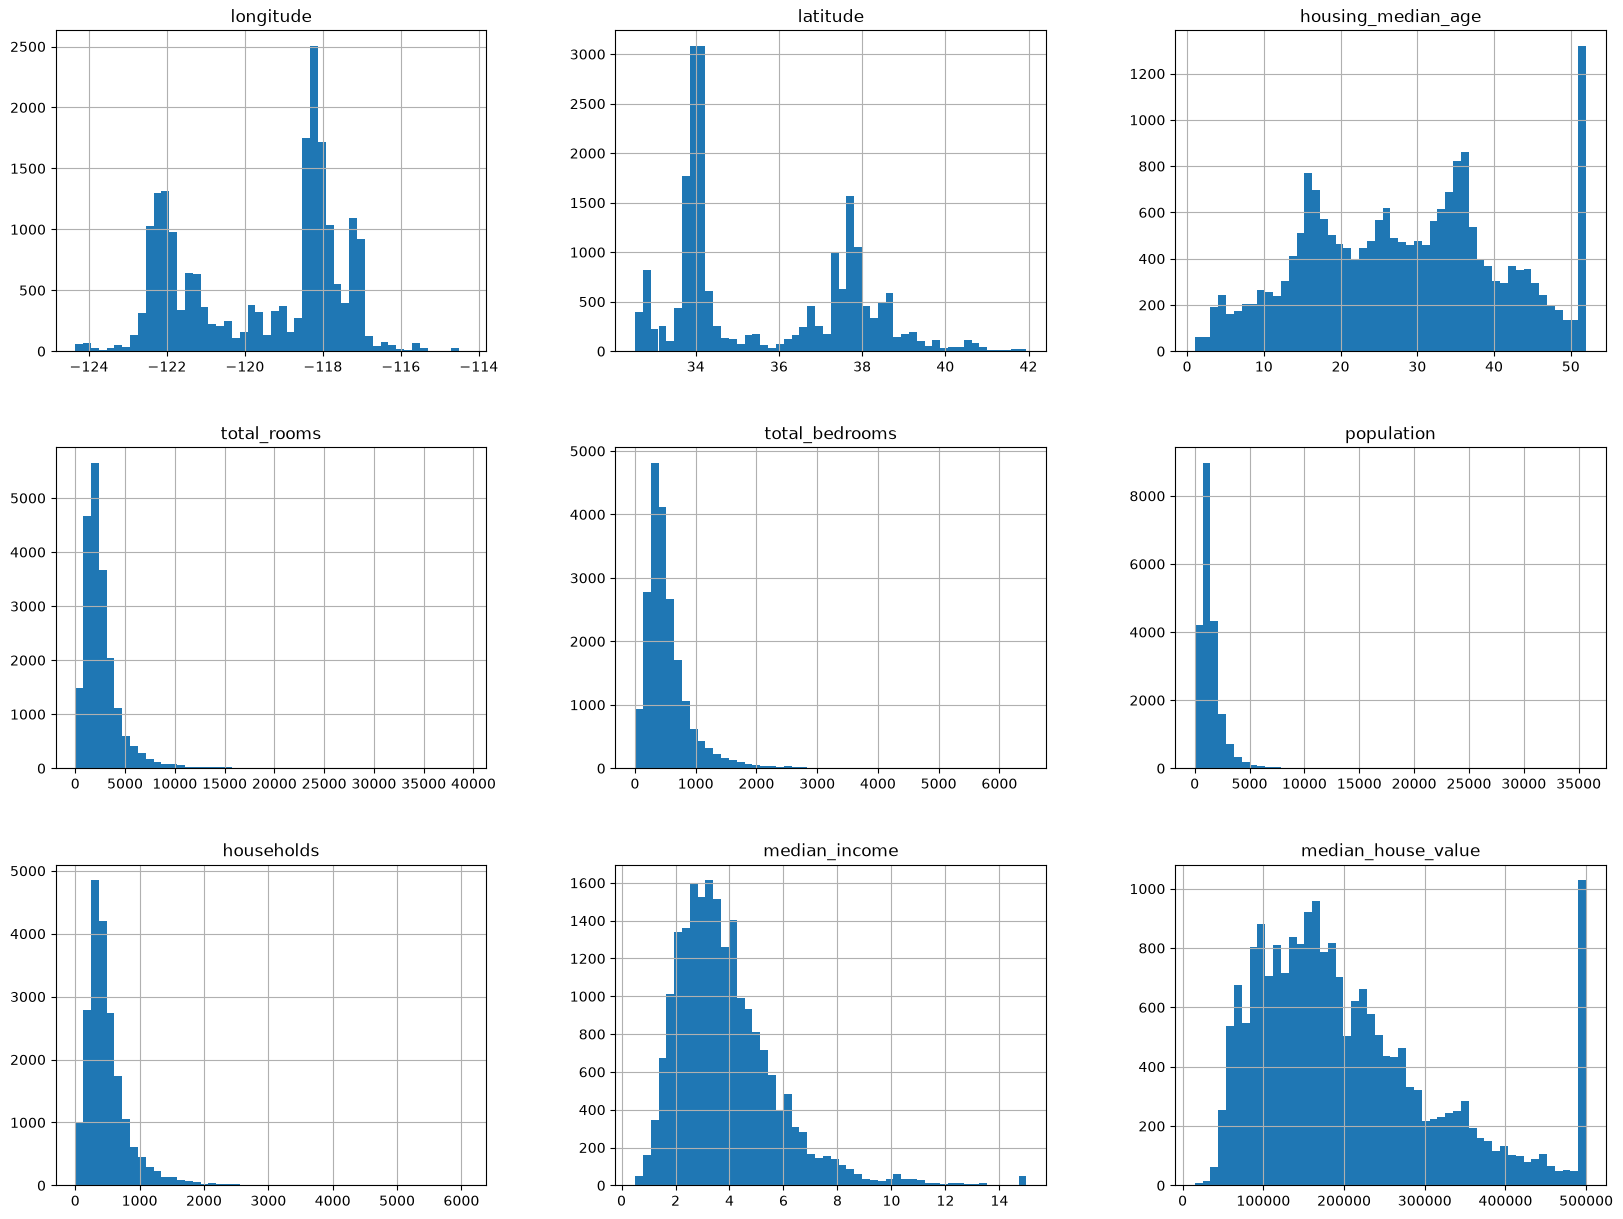

In [31]:
#lets pot the histogram to get the feel of the data 
import matplotlib.pyplot as plt
housing.hist(bins=50,figsize=(20,15))

In [32]:
#lets split the test data 
import numpy as np 
import random
def split_train_test(data,test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    test_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_size]
    train_indices=shuffled_indices[test_size:]
    return data.iloc[train_indices],data.iloc[test_indices]


In [33]:
train_set,test_set=split_train_test(housing,0.2)
print(len(train_set))
print(len(test_set))

16512
4128


In [34]:
# from sklearn.model_selection import StratifiedShuffleSplit

# split = StratifiedShuffleSplit(
#     n_splits=1,
#     test_size=0.2,
#     random_state=42
# )

# for train_index, test_index in split.split(housing, housing["income_category"]):
#     train_set = housing.loc[train_index]
#     test_set = housing.loc[test_index]

# print(len(train_set))
# print(len(test_set))

Original Dataset
        │
        ▼
median_income (continuous)

1.2
2.3
3.7
4.8
7.9
8.5

        │
        ▼
Divide by 1.5

0.8
1.5
2.5
3.2
5.2
5.7

        │
        ▼
Ceil()

1
2
3
4
6
6

        │
        ▼
Merge >5 into 5

1
2
3
4
5
5

        │
        ▼
Stratified Split
        │
        ▼
Train Set + Test Set
(with same income distribution)

        │
        ▼
Delete income_cat

In [35]:
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

C:\Users\ashwa\AppData\Local\Temp\ipykernel_5500\2352722423.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)


In [36]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3.0     0.350533
2.0     0.318798
4.0     0.176357
5.0     0.069041
1.0     0.039729
6.0     0.025678
7.0     0.009205
8.0     0.005087
11.0    0.002422
9.0     0.002422
10.0    0.000727
Name: count, dtype: float64

In [37]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [38]:
housing=strat_train_set.copy()

In [39]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,286600.0,<1H OCEAN
15698,-122.46,37.79,52.0,899.0,96.0,304.0,110.0,14.2959,500001.0,NEAR BAY
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,196900.0,NEAR OCEAN
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,46300.0,INLAND
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,254500.0,<1H OCEAN


In [40]:
housing.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 17606 to 15775
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16356 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.5 MB


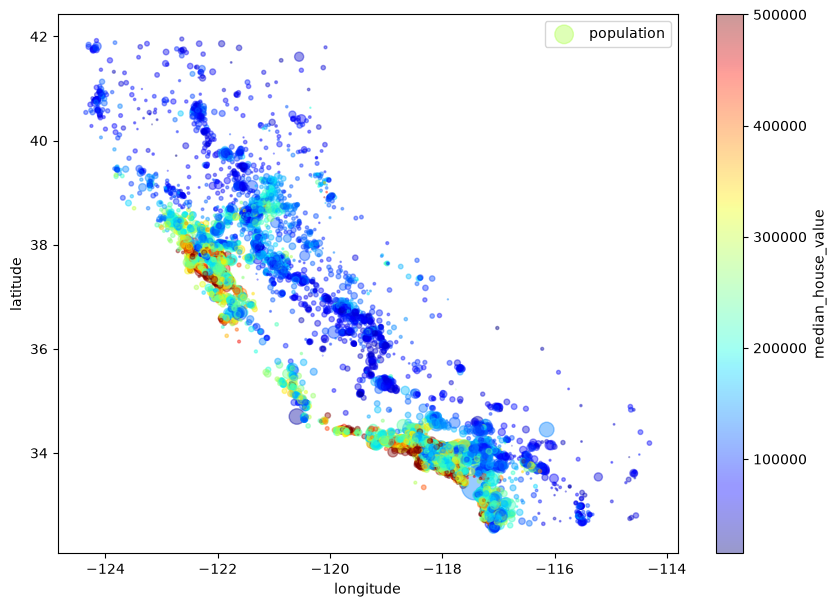

In [41]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
s=housing["population"]/100, label="population", figsize=(10,7),
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

In [42]:
corr_matrix = housing.select_dtypes(include='number').corr()
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924515,-0.109796,0.048963,0.075583,0.107149,0.061549,-0.015589,-0.045056
latitude,-0.924515,1.000000,0.009864,-0.039721,-0.071816,-0.115095,-0.076752,-0.078979,-0.144684
housing_median_age,-0.109796,0.009864,1.000000,-0.363195,-0.324448,-0.297841,-0.305708,-0.116608,0.111770
total_rooms,0.048963,-0.039721,-0.363195,1.000000,0.928874,0.855803,0.917204,0.203718,0.135989
total_bedrooms,0.075583,-0.071816,-0.324448,0.928874,1.000000,0.876225,0.979599,-0.005800,0.049177
population,0.107149,-0.115095,-0.297841,0.855803,0.876225,1.000000,0.905172,0.007472,-0.024765
households,0.061549,-0.076752,-0.305708,0.917204,0.979599,0.905172,1.000000,0.014929,0.065841
median_income,-0.015589,-0.078979,-0.116608,0.203718,-0.005800,0.007472,0.014929,1.000000,0.687474
median_house_value,-0.045056,-0.144684,0.111770,0.135989,0.049177,-0.024765,0.065841,0.687474,1.000000


In [43]:
#checking each attribute correlated with meduan house value
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687474
total_rooms           0.135989
housing_median_age    0.111770
households            0.065841
total_bedrooms        0.049177
population           -0.024765
longitude            -0.045056
latitude             -0.144684
Name: median_house_value, dtype: float64

<Axes: xlabel='median_income', ylabel='median_house_value'>

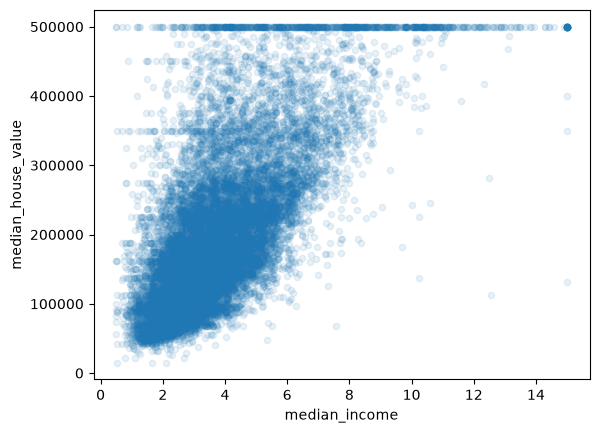

In [44]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
alpha=0.1)

In [45]:
#Handling Text and categorical attributes
housing_cat=housing['ocean_proximity']

Most Machine Learning algorithms prefer to work with numbers anyway, so let’s convert these categories from text to numbers. For this, we can use Pandas’ factorize() method which maps each category to a different integer:

In [47]:
housing_cat_encoded,housing_categories=housing_cat.factorize()

In [48]:
housing_cat_encoded[:10]

array([0, 1, 2, 3, 0, 3, 2, 3, 0, 0])

The factorize()
method also returns the list of categories (“<1H OCEAN” was mapped to 0, “NEAR
OCEAN” was mapped to 1, etc.):

In [49]:
housing_categories

Index(['<1H OCEAN', 'NEAR BAY', 'NEAR OCEAN', 'INLAND', 'ISLAND'], dtype='str')

One issue with this representation is that ML algorithms will assume that two nearby values are more similar than two distant values.
To fix this
issue, a common solution is to create one binary attribute per category: one attribute
equal to 1 when the category is “<1H OCEAN” (and 0 otherwise), another attribute
equal to 1 when the category is “NEAR OCEAN” (and 0 otherwise), and so on. This
is called one-hot encoding, because only one attribute will be equal to 1 (hot), while
the others will be 0 (cold).
Scikit-Learn provides a OneHotEncoder encoder to convert integer categorical values
into one-hot vectors. Let’s encode the categories as one-hot vectors:

In [50]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
housing_cat_1hot=encoder.fit_transform(housing_cat_encoded.reshape(-1,1))
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>